## Célula 1: Imports e Carga dos Dados

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Configurações visuais
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 300

# Encontra diretórios e carrega a base do grupo
root_dir = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/processed/sudeste_municipios.parquet').exists()), None)
if root_dir is None:
    raise FileNotFoundError("Base de dados não encontrada.")

df = pd.read_parquet(root_dir / 'data/processed/sudeste_municipios.parquet')
fig_dir = root_dir / 'outputs/figures'
fig_dir.mkdir(parents=True, exist_ok=True)

print(f"Base carregada com sucesso: {len(df)} municípios.")

Base carregada com sucesso: 1668 municípios.


### 1. Fundamentos Teóricos: Assimetria (Skewness) e Curtose (Kurtosis)

Para compreender se a riqueza gerada no Sudeste é distribuída de forma uniforme ou concentrada em poucos polos, analisamos a forma da distribuição das variáveis econômicas municipais por meio do 3º e 4º momentos estatísticos.

#### Assimetria (Skewness - $S$)
Mede a falta de simetria da distribuição em relação à média:
$$S = \frac{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^3}{\left(\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2\right)^{3/2}}$$

* **$S = 0$**: Distribuição perfeitamente simétrica (ex: Normal).
* **$S > 0$ (Assimetria Positiva / Cauda à Direita)**: A maioria dos municípios concentra-se em valores baixos, mas existe uma minoria com valores extremamente elevados (ex: São Paulo, Rio de Janeiro) que puxa a média para cima.
* **Impacto**: Quando $S > 1$, a média deixa de ser uma medida representativa do município "típico", sendo preferível utilizar a mediana.

#### Curtose de Fisher (Kurtosis - $K$)
Mede o grau de achatamento e o peso das caudas (presença de *outliers* extremados) em relação à distribuição Normal (onde $K = 0$ na definição de Fisher):
$$K = \frac{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^4}{\left(\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2\right)^2} - 3$$

* **$K > 0$ (Leptocúrtica)**: Caudas pesadas e pico acentuado. Indica presença marcante de *outliers* (municípios com PIB ou População ordens de grandeza acima da média).
* **$K \approx 0$ (Mesocúrtica)**: Comportamento semelhante à Normal.

## Célula 2: Cálculo de Assimetria (Skewness) e Curtose (Kurtosis)
Aqui calculamos as métricas estatísticas para PIB, População e PIB per capita, tanto na escala original quanto em $\log_{10}$ para demonstrar o efeito do achatamento de outliers.

In [3]:
# Mapeamento com os nomes exatos das colunas da base do grupo
variaveis = ['pib_total_reais', 'populacao', 'pib_per_capita_reais']
nomes_vars = ['PIB Total', 'População', 'PIB per Capita']

resultados = []

for var, nome in zip(variaveis, nomes_vars):
    dados_orig = df[var].dropna()
    dados_log = np.log10(df[var].replace(0, np.nan).dropna())
    
    resultados.append({
        'Variável': nome,
        'Assimetria (Original)': skew(dados_orig),
        'Curtose (Original)': kurtosis(dados_orig), # Fischer's kurtosis (normal = 0)
        'Assimetria (Log10)': skew(dados_log),
        'Curtose (Log10)': kurtosis(dados_log)
    })

df_metricas = pd.DataFrame(resultados)
display(df_metricas.round(3))

,Variável,Assimetria (Original),Curtose (Original),Assimetria (Log10),Curtose (Log10)
0,PIB Total,30.133,1023.705,0.865,0.492
1,População,27.395,857.418,0.927,1.028
2,PIB per Capita,5.416,40.625,0.864,1.409


#### Interpretação das Métricas Observadas

1. **Escala Bruta (Alta Concentração e Outliers):**
   * O **PIB Total** e a **População** apresentam assimetria positiva extrema ($S \gg 1$) e valores de curtose altíssimos ($K \gg 3$). Isso confirma estatisticamente a forte concentração territorial: pouquíssimas metrópoles dominam o volume produtivo do Sudeste, enquanto a vasta maioria dos $1.668$ municípios possui porte econômico modesto[cite: 4, 7, 8].
   
2. **Efeito da Transformação Logarítmica ($\log_{10}$):**
   * Ao aplicar a escala $\log_{10}$, a assimetria aproxima-se de zero e a curtose reduz-se drasticamente. A transformação estabiliza a variância, suaviza o impacto das grandes capitais e permite modelagens estatísticas e análises correlacionais sem viés de escala.

## Célula 3: Visualização com Boxplots (Escala Bruta vs. Escala Logarítmica)
Geramos os boxplots para evidenciar visualmente a presença de outliers e a cauda longa à direita nas variáveis brutas.

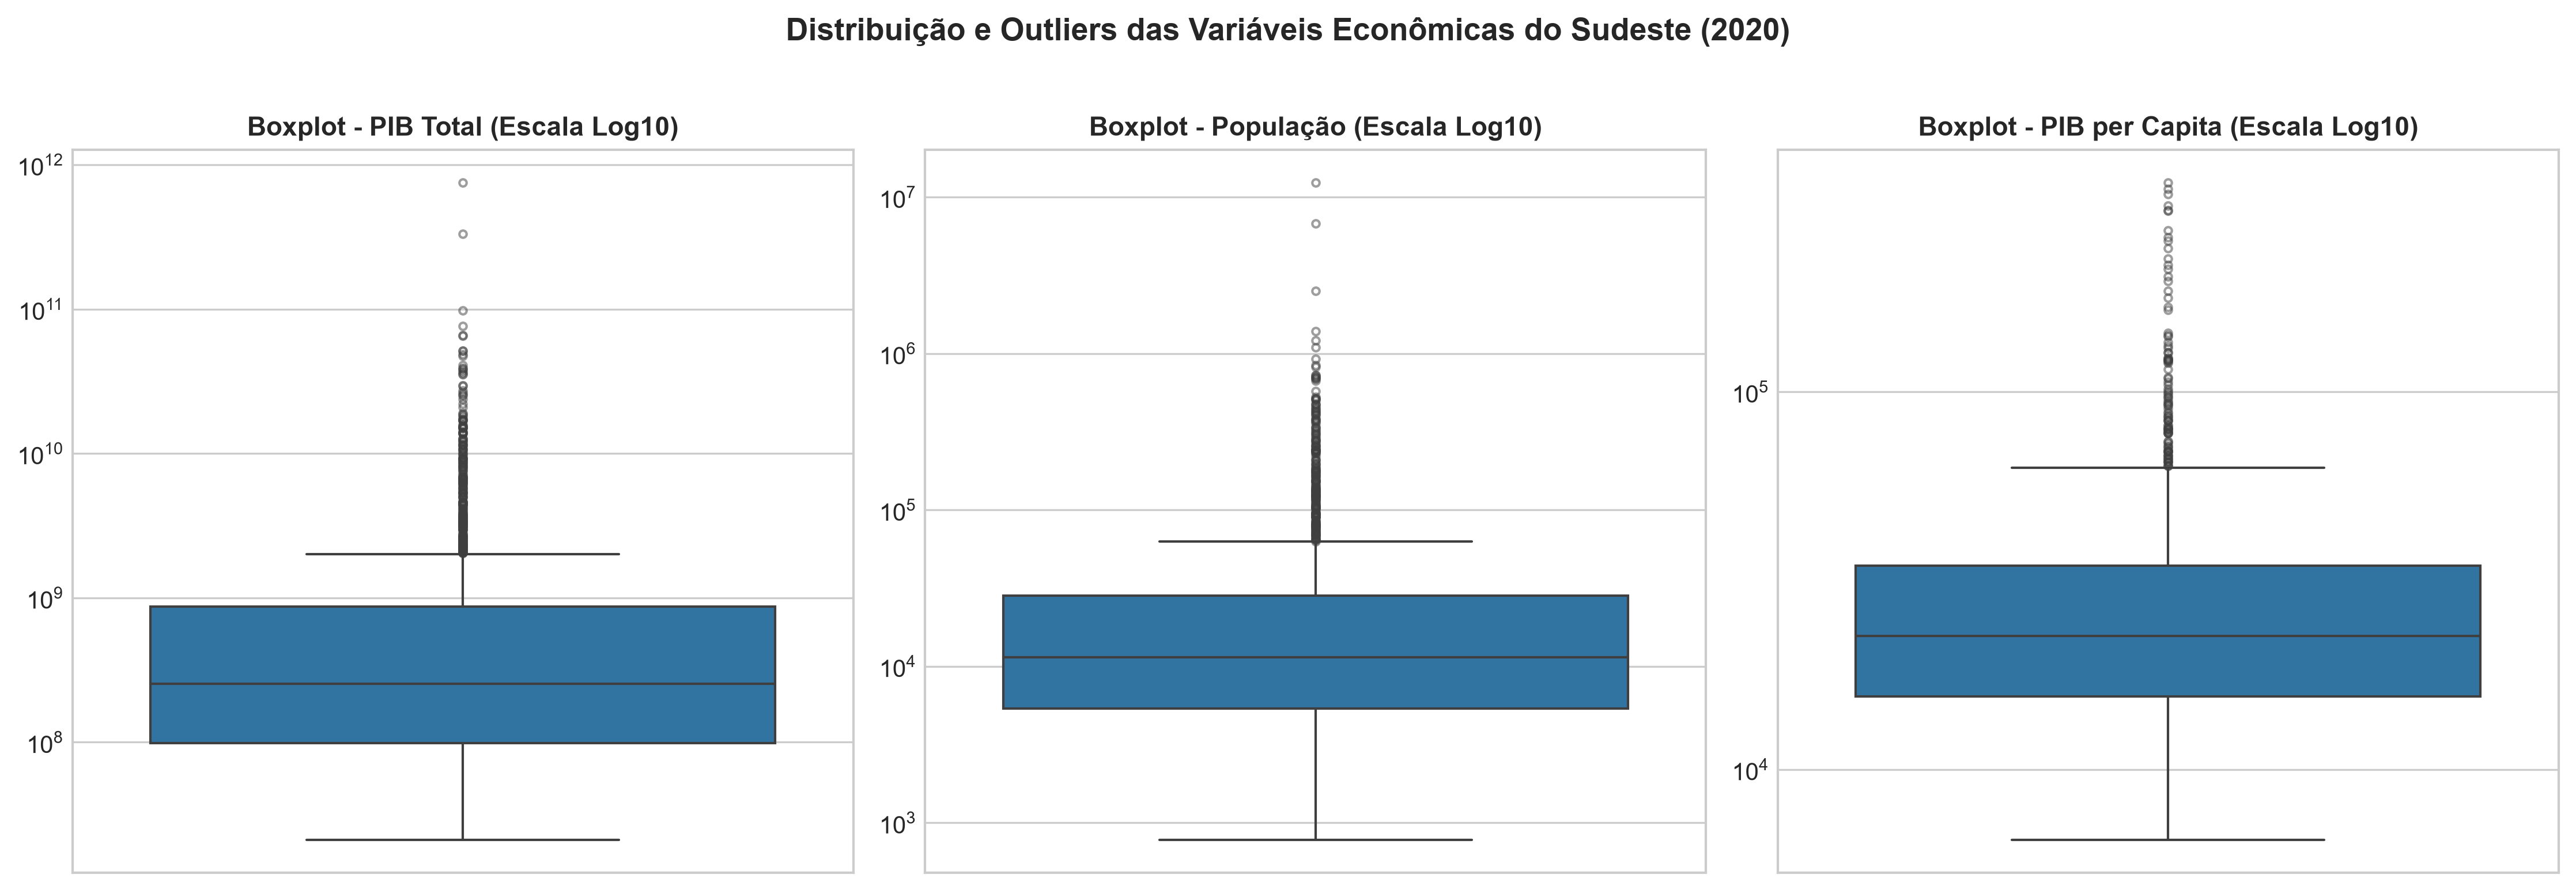

In [6]:
variaveis = ['pib_total_reais', 'populacao', 'pib_per_capita_reais']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (var, nome) in enumerate(zip(variaveis, nomes_vars)):
    sns.boxplot(y=df[var], ax=axes[i], color='#1f77b4', flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5})
    axes[i].set_title(f'Boxplot - {nome} (Escala Log10)', fontsize=11, fontweight='bold')
    axes[i].set_yscale('log')
    axes[i].set_ylabel('')

plt.suptitle('Distribuição e Outliers das Variáveis Econômicas do Sudeste (2020)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(fig_dir / 'boxplots_distribuicao_luis.png', bbox_inches='tight')
plt.show()

## Célula 4: Análise por Estado (Boxplot Comparativo do PIB per Capita)
Compara a distribuição interna e discrepâncias dentro de ES, MG, RJ e SP.

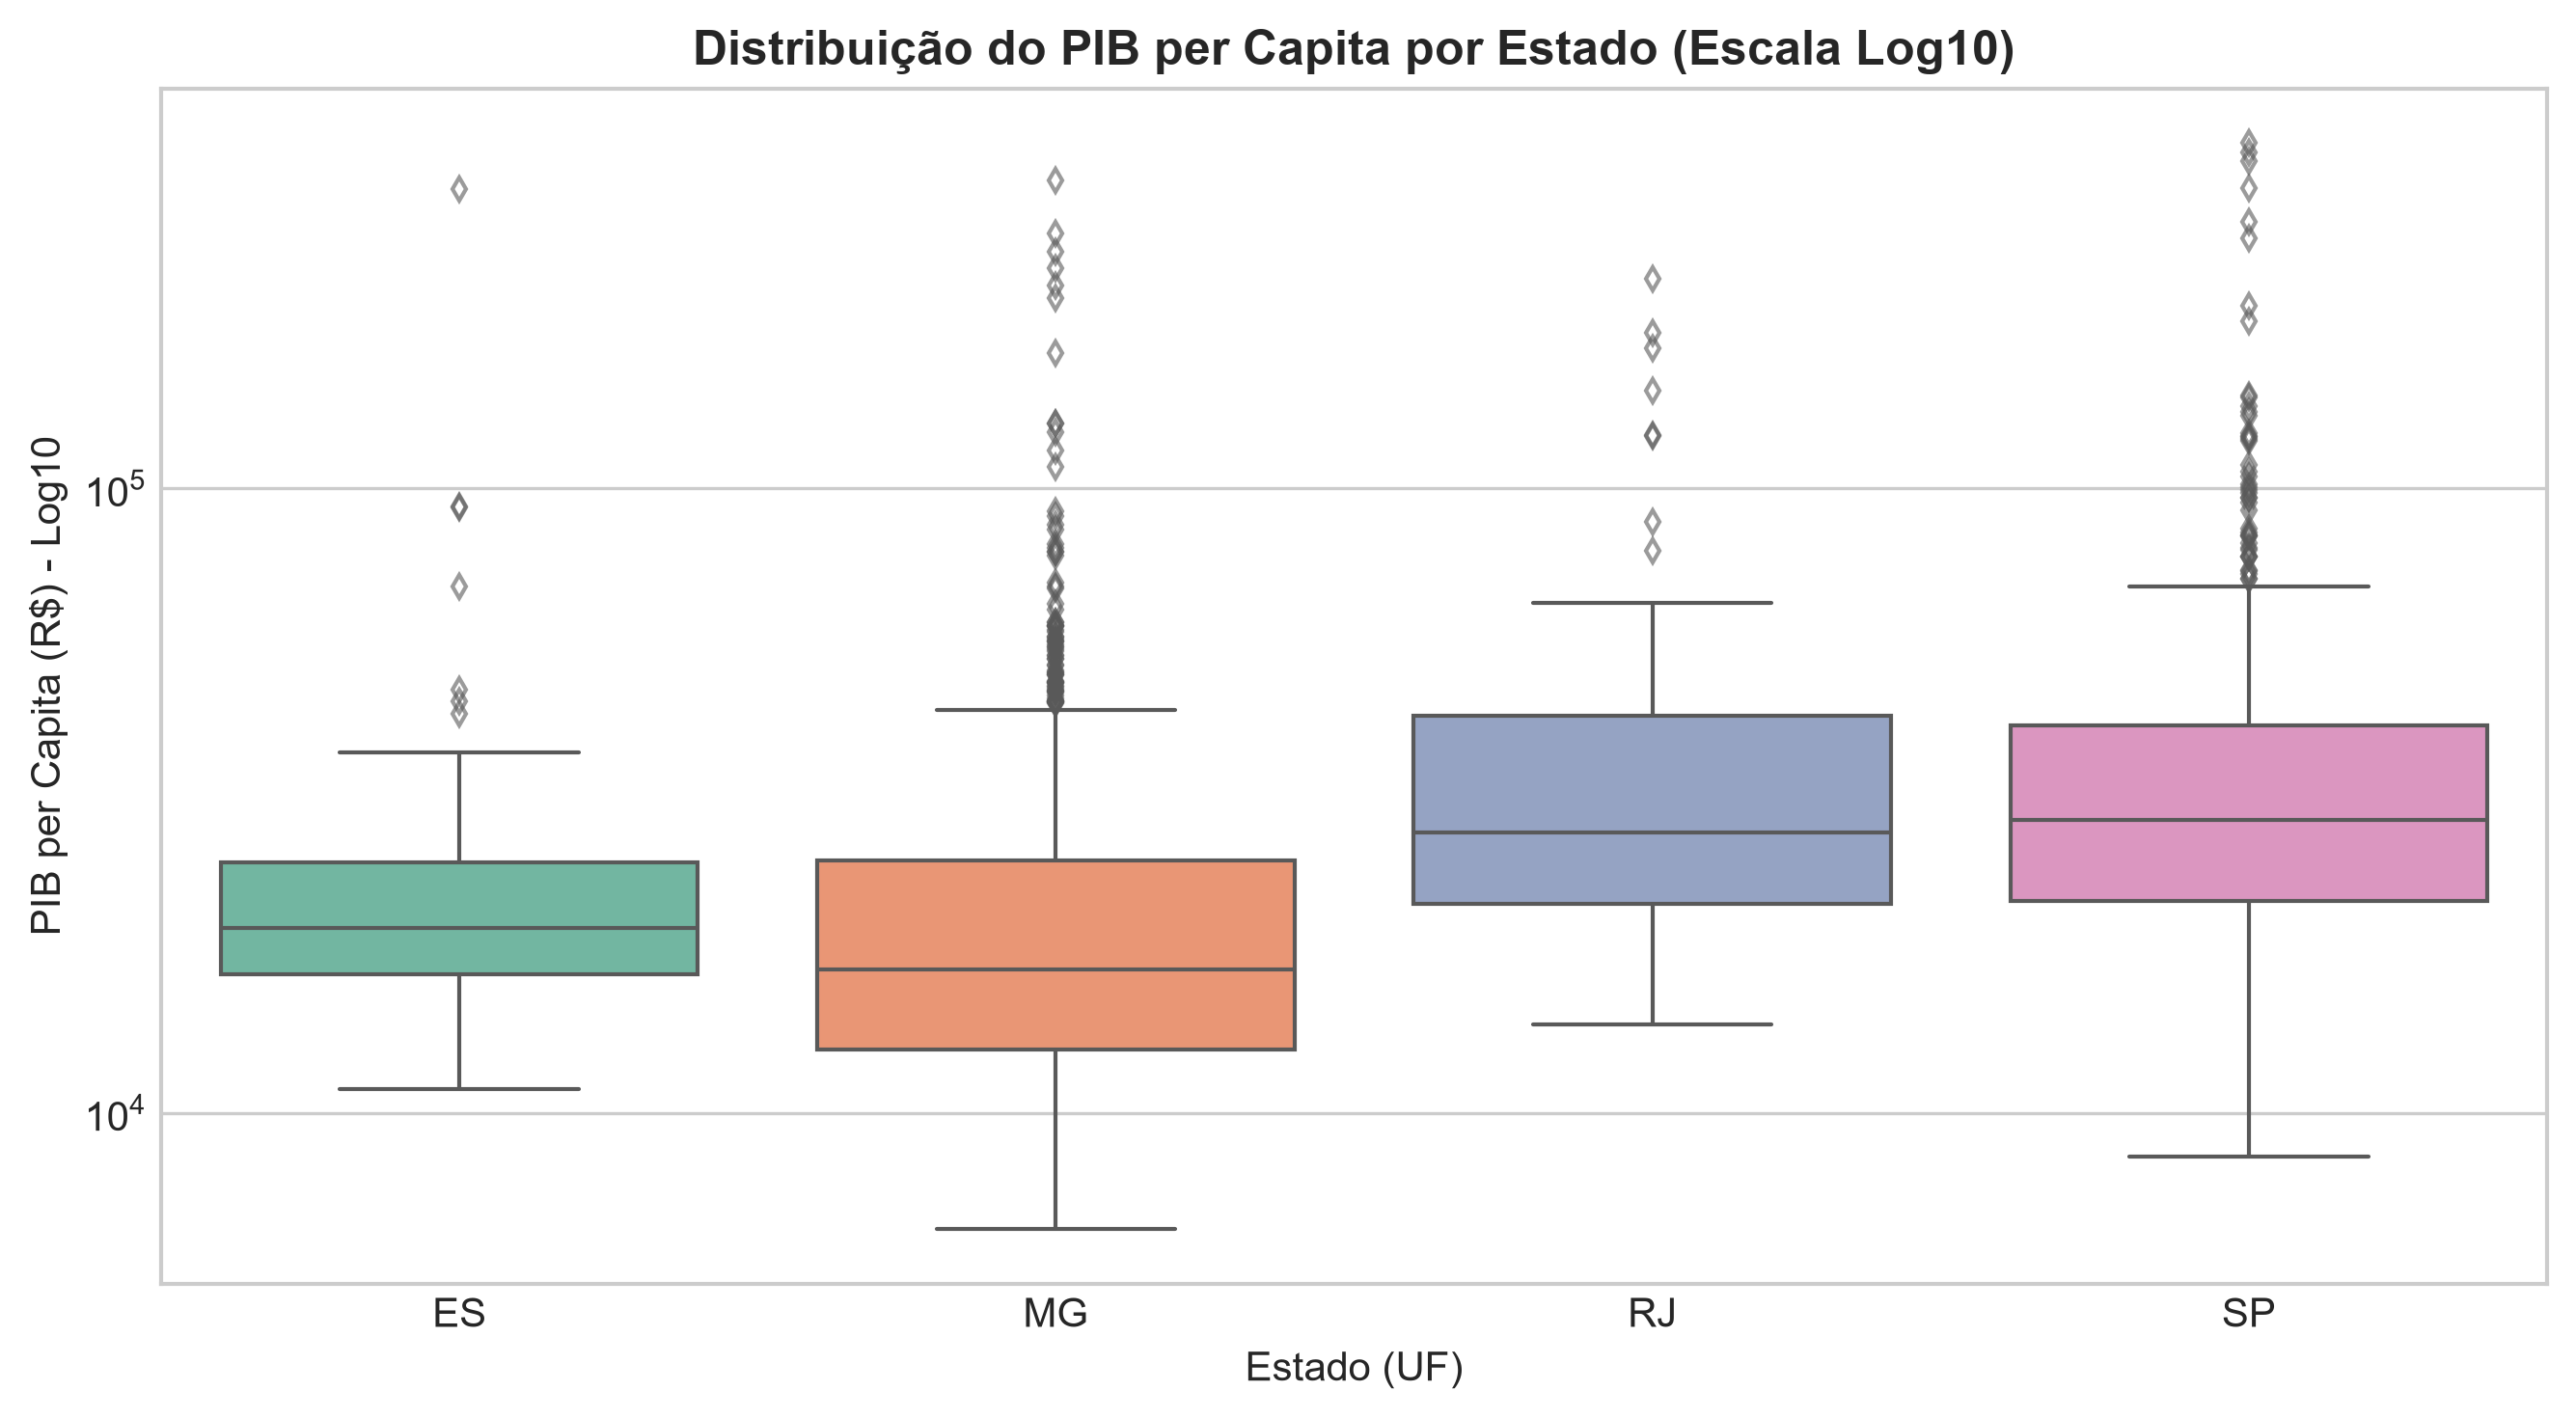

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df, 
    x='uf', 
    y='pib_per_capita_reais',
    hue='uf',
    palette='Set2', 
    legend=False,
    ax=ax,
    flierprops={'marker': 'd', 'markersize': 4, 'alpha': 0.6}
)

ax.set_yscale('log')
ax.set_title('Distribuição do PIB per Capita por Estado (Escala Log10)', fontsize=12, fontweight='bold')
ax.set_xlabel('Estado (UF)')
ax.set_ylabel('PIB per Capita (R$) - Log10')

plt.tight_layout()
plt.savefig(fig_dir / 'boxplot_pib_per_capita_por_uf_luis.png', bbox_inches='tight')
plt.show()

### 3. Limitações Metodológicas da Análise de Distribuição

* **Produção Territorial vs. Bem-Estar Individual:** O PIB *per capita* municipal resulta da divisão da produção bruta territorial pela população residente[cite: 4]. Não mede a renda real apropriada pelas famílias nem a desigualdade interna (como o Coeficiente de Gini do rendimento domiciliado)[cite: 4].
* **Efeito Comutação (Commuting):** Municípios industriais ou petrolíferos com população pequena podem apresentar um PIB *per capita* artificialmente elevado sem que esse valor reflita a qualidade de vida da população local.
* **Escala Espacial Agregada:** A análise ao nível municipal oculta as disparidades intraurbanas (segregação espacial e periferização dentro das próprias metrópoles).

### Conclusões Gerais da Análise de Distribuição e Desigualdade
1. **Forte Assimetria Positiva (Cauda Longa à Direita):**
   * As variáveis econômicas brutas (PIB e População) apresentam **assimetria altamente positiva** e **alta curtose (leptocúrtica)**, indicando que a grande maioria dos municípios possui valores modestos, enquanto uma minoria (como capitais e polos industriais) concentra volumes desproporcionalmente altos.

2. **Necessidade da Transformação Logarítmica:**
   * A aplicação da escala $\log_{10}$ reduz drasticamente a assimetria e a curtose, aproximando as variáveis de uma distribuição normal e permitindo analisar municípios pequenos e grandes na mesma métrica visual.

3. **Disparidades Intra e Interestaduais:**
   * Os boxplots revelam uma presença expressiva de *outliers* superiores em todos os estados. Embora São Paulo apresente a maior mediana de PIB per capita, a variabilidade interna dentro de cada estado confirma que a desigualdade de produção não ocorre apenas entre regiões, mas fortemente no nível municipal.